========== LOADING TRAIN DATA ==========
Train samples: 399

========== TRAINING MODEL ==========
Training completed!

========== TEST RESULT ==========

01. test_cat_0.jpg       Actual: cat Predict: dog ✗
02. test_cat_1.jpg       Actual: cat Predict: cat ✓
03. test_cat_10.jpg      Actual: cat Predict: dog ✗
04. test_cat_11.jpg      Actual: cat Predict: dog ✗
05. test_cat_12.jpg      Actual: cat Predict: cat ✓
06. test_cat_13.jpg      Actual: cat Predict: cat ✓
07. test_cat_14.jpg      Actual: cat Predict: dog ✗
08. test_cat_15.jpg      Actual: cat Predict: cat ✓
09. test_cat_16.jpg      Actual: cat Predict: cat ✓
10. test_cat_17.jpg      Actual: cat Predict: cat ✓
11. test_cat_18.jpg      Actual: cat Predict: cat ✓
12. test_cat_19.jpg      Actual: cat Predict: cat ✓
13. test_cat_2.jpg       Actual: cat Predict: cat ✓
14. test_cat_20.jpg      Actual: cat Predict: cat ✓
15. test_cat_21.jpg      Actual: cat Predict: cat ✓
16. test_cat_22.jpg      Actual: cat Predict: dog ✗
17. test_cat_2

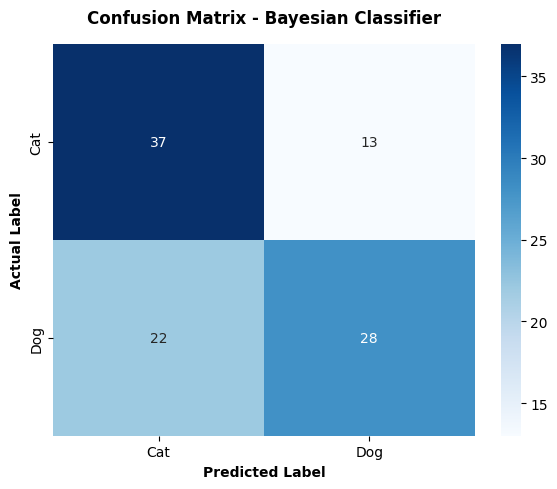

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from skimage.feature import hog, graycomatrix, graycoprops
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Tắt warning
warnings.filterwarnings("ignore")

# =====================================================
# HÀM TRÍCH XUẤT ĐẶC TRƯNG
# =====================================================
def Extract_Advanced_Features(img_path):
    img = cv2.imread(img_path)

    if img is None:
        print(f"Không đọc được ảnh: {img_path}")
        return None

    img = cv2.resize(img, (128, 128))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Đặc trưng màu sắc
    avg_color = np.mean(img, axis=(0, 1))

    # Đặc trưng texture (GLCM)
    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, 'contrast')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]

    # Đặc trưng HOG
    hog_feature = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False
    )

    feature = np.hstack((
        avg_color,
        contrast,
        correlation,
        hog_feature
    ))

    return feature

# =====================================================
# CLASS: BAYESIAN CLASSIFIER
# =====================================================
def normal_pdf(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

class NaiveBayesClassifier:
    def __init__(self):
        self.classes = None
        self.stats = {}

    def fit(self, X, y):
        self.classes = np.unique(y)
        for c in self.classes:
            X_c = X[y == c]
            self.stats[c] = {
                'mean': np.mean(X_c, axis=0),
                'std': np.std(X_c, axis=0) + 1e-6, # Tránh lỗi chia cho 0
                'prior': X_c.shape[0] / X.shape[0]
            }

    def predict(self, X):
        y_pred = []
        for x in X:
            posteriors = []
            for c in self.classes:
                prior = np.log(self.stats[c]['prior'])
                # Tính tổng log likelihood để tránh lỗi số quá nhỏ (underflow)
                likelihood = np.sum(np.log(normal_pdf(x, self.stats[c]['mean'], self.stats[c]['std']) + 1e-90))
                posteriors.append(prior + likelihood)
            y_pred.append(self.classes[np.argmax(posteriors)])
        return np.array(y_pred)

# =====================================================
# ĐỌC DỮ LIỆU TRAIN
# =====================================================

csv_path = "../data/dog_cat_features.csv"

if not os.path.exists(csv_path):
    print("Không tìm thấy file:", csv_path)
    exit()

print("========== LOADING TRAIN DATA ==========")

df = pd.read_csv(csv_path)

print("Train samples:", len(df))

# Chuyển Dataframe sang mảng Numpy cho thuật toán code tay
X_train = df.drop(columns=["Label"]).values 
y_train = df["Label"].values

# =====================================================
# HUẤN LUYỆN MÔ HÌNH
# =====================================================

print("\n========== TRAINING MODEL ==========")

# Sử dụng class code tay thay vì thư viện sklearn
model = NaiveBayesClassifier()

model.fit(X_train, y_train)

print("Training completed!")

# =====================================================
# DỰ ĐOÁN TRÊN THƯ MỤC TEST
# =====================================================

test_dir = "../data/test"

actual = []
predicted = []

print("\n========== TEST RESULT ==========\n")

count = 1

for category in ["cat", "dog"]:

    folder = os.path.join(test_dir, category)

    if not os.path.exists(folder):
        print("Không tìm thấy thư mục:", folder)
        continue

    for file in sorted(os.listdir(folder)):

        img_path = os.path.join(folder, file)

        feature = Extract_Advanced_Features(img_path)

        if feature is None:
            continue

        # Dự đoán trực tiếp bằng mảng Numpy
        pred = model.predict([feature])[0]

        actual.append(category)
        predicted.append(pred)

        status = "✓" if pred == category else "✗"

        print(f"{count:02d}. {file:<20} Actual: {category:<3} Predict: {pred:<3} {status}")

        count += 1

# =====================================================
# KẾT QUẢ ĐÁNH GIÁ (ACCURACY & REPORT & MATRIX)
# =====================================================

accuracy = accuracy_score(actual, predicted)

print("\n========================================")
print(f"Accuracy = {accuracy * 100:.2f}%")
print("========================================")

print("\nClassification Report\n")
print(classification_report(
    actual,
    predicted,
    labels=["cat", "dog"],
    target_names=["cat", "dog"]
))

# Vẽ Confusion Matrix
cm = confusion_matrix(
    actual,
    predicted,
    labels=["cat", "dog"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues", 
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"]
)

plt.xlabel("Predicted Label", fontweight='bold')
plt.ylabel("Actual Label", fontweight='bold')
plt.title("Confusion Matrix - Bayesian Classifier", fontweight='bold', pad=15)

plt.tight_layout()
plt.show()